In [442]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import category_encoders as ce
from sklearn import preprocessing
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestRegressor 
from sklearn import metrics 

from collections import Counter

In [368]:
# Чтение файла
df = pd.read_csv('hotels.csv')
df.tail()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
386798,9 Knaresborough Place Kensington and Chelsea L...,107,4/19/2017,9.0,Hotel Moonlight,France,No Negative,0,617,Tr s proche du metro Earl s court,10,10,8.8,"[' Leisure trip ', ' Group ', ' Club Double or...",106 day,51.494028,-0.191050
386799,Landstra er Hauptstra e 155 03 Landstra e 1030...,272,2/13/2017,8.4,BEST WESTERN PLUS Amedia Wien,Turkey,No Negative,0,3224,The bed was so comfy I stayed with my boyfrie...,93,1,9.2,"[' Leisure trip ', ' Couple ', ' Standard Doub...",171 day,48.192379,16.399451
386800,29 31 Gower Street Camden London WC1E 6HG Unit...,457,2/7/2016,6.8,Bloomsbury Palace Hotel,Netherlands,room is really small but guess is normal in L...,12,2751,great location simple check in out nice shower,9,21,8.3,"[' Business trip ', ' Solo traveler ', ' Singl...",543 day,51.520795,-0.131084
386801,31 Great Cumberland Place Westminster Borough ...,365,5/21/2017,8.1,The Marble Arch London,United Arab Emirates,No Negative,0,1567,Location and very comfy bed,6,28,9.2,"[' Leisure trip ', ' Solo traveler ', ' Deluxe...",74 days,51.515125,-0.160066
386802,25 Courtfield Gardens Kensington and Chelsea L...,222,8/5/2016,9.0,The Nadler Kensington,Australia,Patio outside could have been cleaned of alga...,20,1209,Beds comfortable Pillows also good Homely fee...,20,2,8.8,"[' Leisure trip ', ' Couple ', ' Bunk Bed Room...",363 day,51.493109,-0.190208


**Информация о столбцах таблицы**

* hotel_address — адрес отеля;
* review_date — дата, когда рецензент разместил соответствующий отзыв;
* average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
* hotel_name — название отеля;
* reviewer_nationality — страна рецензента;
* negative_review — отрицательный отзыв, который рецензент дал отелю;
* review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
* positive_review — положительный отзыв, который рецензент дал отелю;
* review_total_positive_word_counts — общее количество слов в положительном отзыве;
* reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
* total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
* total_number_of_reviews — общее количество действительных отзывов об отеле;
* tags — теги, которые рецензент дал отелю;
* days_since_review — количество дней между датой проверки и датой очистки;
* additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
* lat — географическая широта отеля;
* lng — географическая долгота отеля.

<h3>Описательный анализ данных</h3>

In [369]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

hotel_address                                    0
additional_number_of_scoring                     0
review_date                                      0
average_score                                    0
hotel_name                                       0
reviewer_nationality                             0
negative_review                                  0
review_total_negative_word_counts                0
total_number_of_reviews                          0
positive_review                                  0
review_total_positive_word_counts                0
total_number_of_reviews_reviewer_has_given       0
reviewer_score                                   0
tags                                             0
days_since_review                                0
lat                                           2448
lng                                           2448
dtype: int64

Cтолбцы lat и lng имеют по 2448 пропусков, столбцы представляют собой информацию о географическом расположении отеля. 

In [370]:
print('Количество дубликатов - ' + str(df[df.duplicated].shape[0]))
print(f'Количество строк до удаления дубликатов - {df.shape[0]}')
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Количество строк после удаления дубликатов {df.shape[0]}')

Количество дубликатов - 307
Количество строк до удаления дубликатов - 386803
Количество строк после удаления дубликатов 386496


<h3>Заполнение пустых значений в столбцах lat и lng</h3>

Заполнять пропуски мы будем проходясь по каждой строчке таблицы, если обнаружен пропуск, то будет запущена дополнительная функция для поиска отеля по адресу, если не найден по адресу, то по названию, если не найдено ничего то значение будет заполнено значением до этого пропущенного значения. 

In [371]:
df[df['lat'].isna()].shape

(2448, 17)

Мы удостоверились, в том, что если пропущено значений lat то будет пропущено и значение lng.

In [372]:
def search_passes(df):
    # Создаем отдельный DataFrame только с заполненными координатами для поиска
    df_filled = df[df['lat'].notna()].copy()
    
    # Счетчики
    filled_by_address = 0
    filled_by_hotel_name = 0
    filled_by_previous = 0
    still_empty = 0
    
    def fill_passes_hotel_name(i):
        nonlocal filled_by_hotel_name, filled_by_previous, still_empty
        
        hotel_name = df.loc[i, 'hotel_name']
        # Ищем только в заполненных данных
        matches = df_filled[df_filled['hotel_name'] == hotel_name]
        if not matches.empty:
            filled_by_hotel_name += 1
            return matches.iloc[0]['lat'], matches.iloc[0]['lng']
        
        # Если не нашли, используем предыдущую строку (если она не NaN)
        if i > 0 and not pd.isna(df.loc[i-1, 'lat']):
            filled_by_previous += 1
            return df.loc[i-1, 'lat'], df.loc[i-1, 'lng']
        else:
            still_empty += 1
            return np.nan, np.nan

    def fill_passes_address(i):
        nonlocal filled_by_address
        
        address = df.loc[i, 'hotel_address']
        # Ищем только в заполненных данных
        matches = df_filled[df_filled['hotel_address'] == address]
        if not matches.empty:
            filled_by_address += 1
            return matches.iloc[0]['lat'], matches.iloc[0]['lng']
        
        return fill_passes_hotel_name(i)

    # Считаем начальное количество пропусков
    initial_empty = df['lat'].isna().sum()
    
    for i in range(df.shape[0]):
        if pd.isna(df.loc[i, 'lat']):
            result = fill_passes_address(i)
            if not pd.isna(result[0]):
                df.loc[i, 'lat'] = result[0]
                df.loc[i, 'lng'] = result[1]

    # Финальная статистика
    final_empty = df['lat'].isna().sum()
    
    print("=== РЕЗУЛЬТАТЫ ЗАПОЛНЕНИЯ ===")
    print(f"Изначально пропусков: {initial_empty}")
    print(f"Заполнено по адресу: {filled_by_address}")
    print(f"Заполнено по названию отеля: {filled_by_hotel_name}")
    print(f"Заполнено предыдущей строкой: {filled_by_previous}")
    print(f"Осталось пустых: {still_empty}")
    print(f"Всего заполнено: {filled_by_address + filled_by_hotel_name + filled_by_previous}")
    print(f"Финальное количество пропусков: {final_empty}")

    return df

df = search_passes(df)

=== РЕЗУЛЬТАТЫ ЗАПОЛНЕНИЯ ===
Изначально пропусков: 2448
Заполнено по адресу: 0
Заполнено по названию отеля: 0
Заполнено предыдущей строкой: 2448
Осталось пустых: 0
Всего заполнено: 2448
Финальное количество пропусков: 0


По результату исходящий данных от заполнения пропусков можно сказать, что все отели у которых отсутствовали координаты, никогда небыли в этой таблице.

<h3>Очищение данных от выбросов</h3>

<h5>Изучение данных для additional_number_of_scoring</h5>

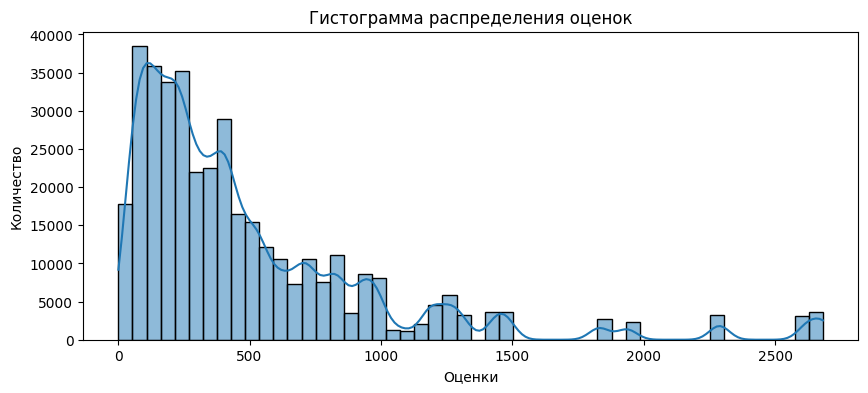

Статистические данные:


,additional_number_of_scoring
count,386496.00
mean,498.50
std,500.37
min,1.00
25%,169.00
50%,342.00
75%,660.00
max,2682.00


Количество распределения оценок:


,count
additional_number_of_scoring,
2682,3587
2288,3206
2623,3095
1831,2688
1936,2379
...,...
8,38
5,33
17,18


In [373]:
fig = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=df,
    x='additional_number_of_scoring',
    bins=50,
    kde=True)

plt.xlabel('Оценки') 
plt.ylabel('Количество') 
plt.title('Гистограмма распределения оценок') 
plt.show() 

print('Статистические данные:')
display(df['additional_number_of_scoring'].describe().round(2).to_frame())
print('Количество распределения оценок:')
display(df['additional_number_of_scoring'].value_counts(normalize=False).sort_values(ascending=False).to_frame())

Данные распределены ненормально. Выбросов нет.

<h5>Изучение данных для average_score</h5>

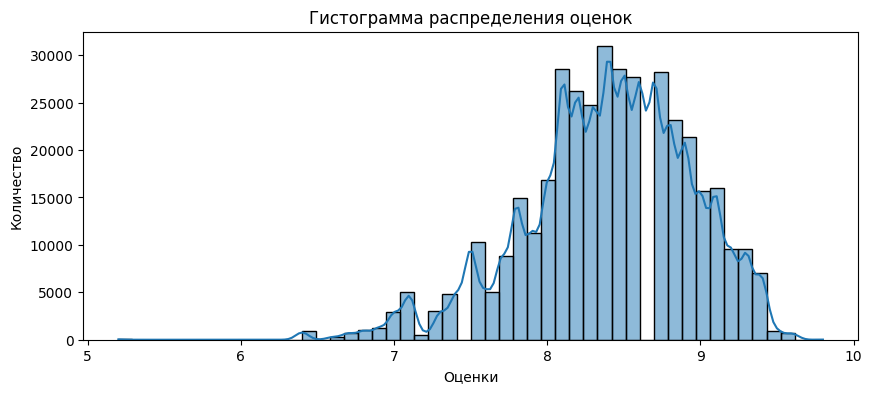

Статистические данные:


,average_score
count,386496.00
mean,8.40
std,0.55
min,5.20
25%,8.10
50%,8.40
75%,8.80
max,9.80


Количество распределения оценок:


,count
average_score,
8.4,30929
8.5,28531
8.1,28527
8.7,28199
8.6,27713
8.2,26174
8.3,24731
8.8,23178
8.9,21413


In [374]:
fig = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=df,
    x='average_score',
    bins=50,
    kde=True)

plt.xlabel('Оценки') 
plt.ylabel('Количество') 
plt.title('Гистограмма распределения оценок') 
plt.show() 

print('Статистические данные:')
display(df['average_score'].describe().round(2).to_frame())
print('Количество распределения оценок:')
display(df['average_score'].value_counts(normalize=False).sort_values(ascending=False).to_frame())

Данные распределены нормально (по визуализации). Выбросов нет.

<h5>Изучение данных для review_total_negative_word_counts</h5>

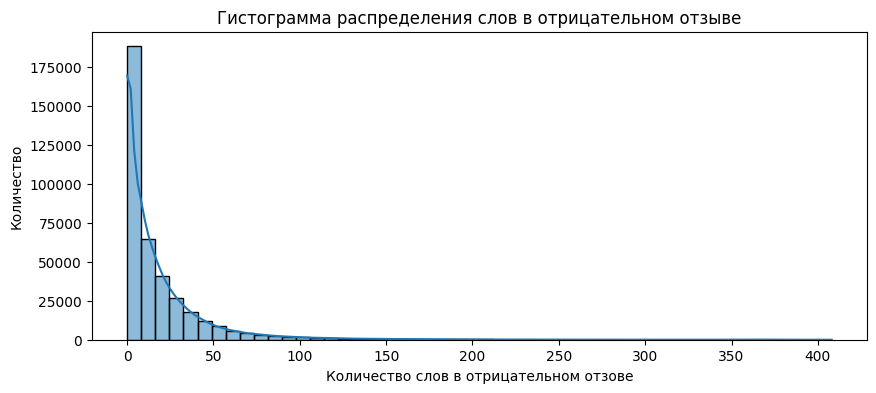

Статистические данные:


,review_total_negative_word_counts
count,386496.00
mean,18.54
std,29.70
min,0.00
25%,2.00
50%,9.00
75%,23.00
max,408.00


Количество распределения оценок:


,count
review_total_negative_word_counts,
0,95833
2,18470
3,13640
6,13274
5,12614
...,...
332,1
401,1
408,1


In [375]:
fig = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=df,
    x='review_total_negative_word_counts',
    bins=50,
    kde=True)

plt.xlabel('Количество слов в отрицательном отзове') 
plt.ylabel('Количество') 
plt.title('Гистограмма распределения слов в отрицательном отзыве') 
plt.show() 


print('Статистические данные:')
display(df['review_total_negative_word_counts'].describe().round(2).to_frame())
print('Количество распределения оценок:')
display(df['review_total_negative_word_counts'].value_counts(normalize=False).sort_values(ascending=False).to_frame())

В данном случае возможны выбросы, но количество слов каждый раз практически индивидуально. Тем более присутствует более 10 отрицательных отзывов с количеством слов более 400. Поэтому нет необходимости удалять данные.

<h5>Распределения для остальных признако</h5>

Для экономии времени и места, будет использовать общий график оставшихся распределений. (total_number_of_reviews, review_total_positive_word_counts, total_number_of_reviews_reviewer_has_given, reviewer_score, lat, lng)

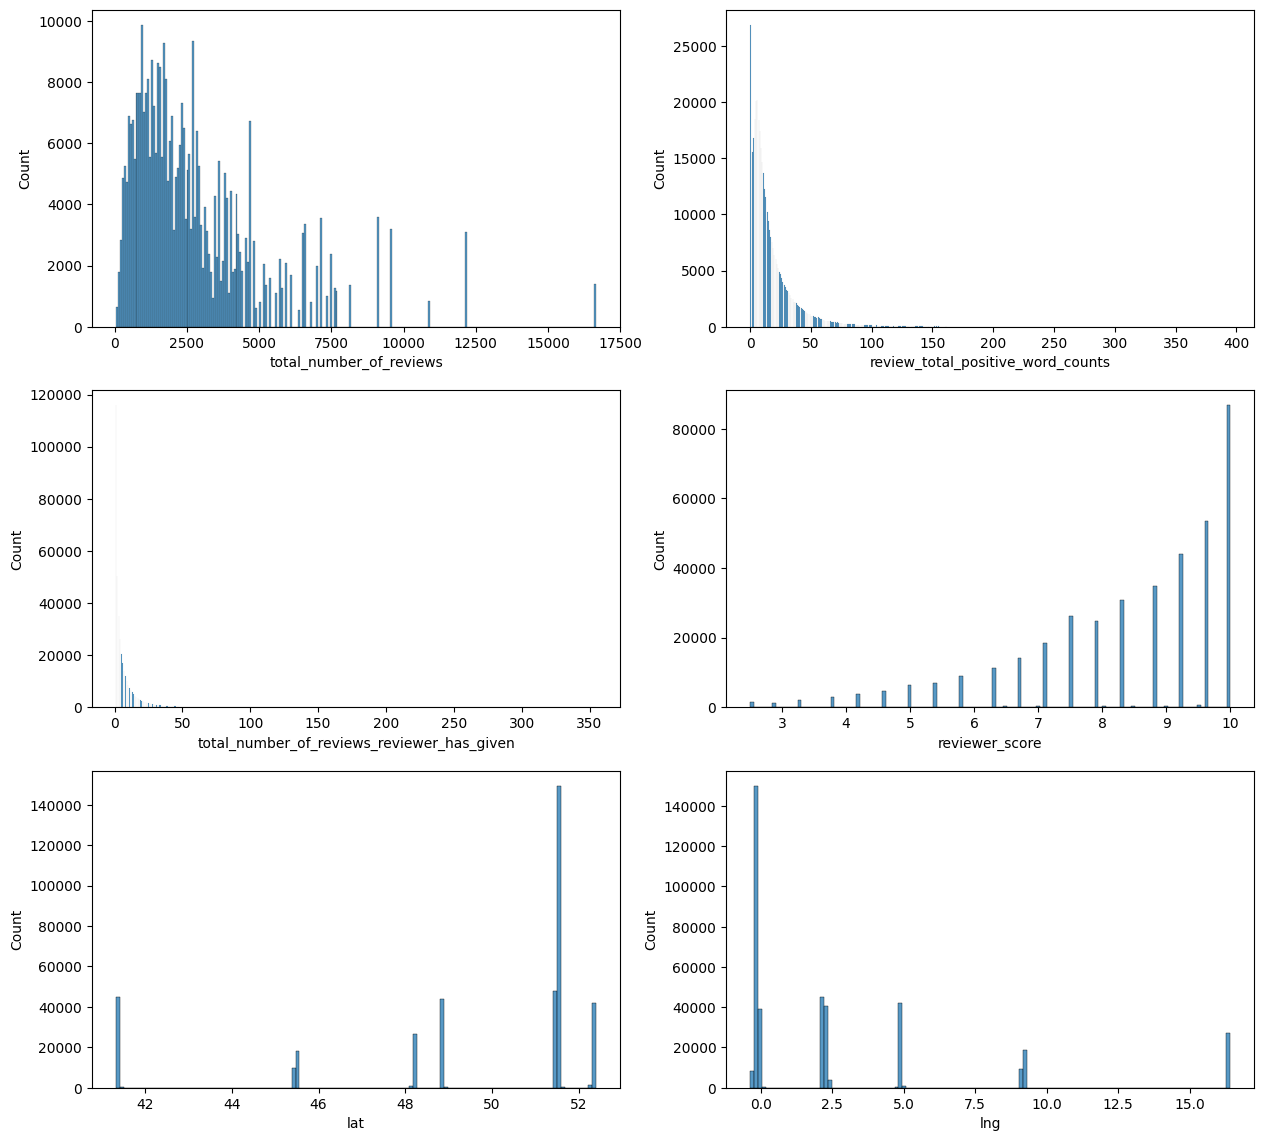

In [376]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14))

sns.histplot(data=df, x='total_number_of_reviews', ax=axes[0, 0])
sns.histplot(data=df, x='review_total_positive_word_counts', ax=axes[0, 1])
sns.histplot(data=df, x='total_number_of_reviews_reviewer_has_given', ax=axes[1, 0])
sns.histplot(data=df, x='reviewer_score', ax=axes[1, 1])
sns.histplot(data=df, x='lat', ax=axes[2, 0])
sns.histplot(data=df, x='lng', ax=axes[2, 1])
plt.show()

По оси Y - количество.\
По оси X -  значения.\
Наименомание признаков под графиком.

По данным распределениями можно сказать, что данные не имеют выбросов.

<h3>Преобразование, кодирование категориальных признаков и удаление неинформативных</h3>

In [377]:
df.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


* hotel_address - удаление. Неинформативен, сложно вытащить какие-либо данные.
* review_date - удаление. Не считаю, что рейтинг отеля зависит от даты размещения отзыва.
* hotel_name - кодирование бинарным способом (из-за большого количества уникальных значений).
* reviewer_nationality - кодирование бинарным способом (из-за большого количества уникальных значений).
* negative_review - удаление. Неинформативен.
* positive_review - удаление. Неинформативен.
* tags - кодирование 20-и самых популярных тегов.
* days_since_review - преобразование.

<h5>Удаление неинформативных категориальных признаков</h5>

In [378]:
df.drop(columns=['hotel_address', 'review_date', 'negative_review', 'positive_review'], inplace=True)
df.head()

,additional_number_of_scoring,average_score,hotel_name,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,581,8.4,The May Fair Hotel,United Kingdom,3,1994,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,299,8.3,Mercure London Bloomsbury Hotel,United Kingdom,3,1361,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,32,8.9,Legend Saint Germain by Elegancia,China,6,406,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,34,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,0,607,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,914,8.5,Golden Tulip Amsterdam West,Poland,4,7586,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


<h5>Преобразование признака days_since_review</h5>

In [379]:
def change_days_si_re(string):
    lst = string.split()
    return int(lst[0])

df['days_since_review'] = df['days_since_review'].apply(change_days_si_re)

<h5>Кодировка признаков</h5>

Кодировка для hotel_name

In [382]:
bin_encoder = ce.BinaryEncoder(cols=['hotel_name'])
type_bin = bin_encoder.fit_transform(df['hotel_name'])
df = pd.concat([df, type_bin], axis=1)

Кодировка для reviewer_nationality

In [385]:
bin_encoder = ce.BinaryEncoder(cols=['reviewer_nationality'])
type_bin = bin_encoder.fit_transform(df['reviewer_nationality'])
df = pd.concat([df, type_bin], axis=1)

Кодировка для tags\
Закодировать данный признак при помощи BinaryEncoder нельзя, потому воспользуясь счетчиком я возьму 20 самых популярных значений и тогда их закодирую.

In [404]:
def encoding_tags(df): # Ф-я для кодирования признака tags

    def count_tags(df): # Подсчет значений
        counter = Counter()

        for i in range(df.shape[0]):
            tags = df.loc[i, 'tags']
            tag = tags.replace('"', '').replace("'", "").replace('[', '').replace(']', '')
            tag_list = tag.split(',')

            for n in tag_list:
                counter.update([n])

        return counter
    

    def encoding_tags(df, counter): # Сама кодировка

        def encod_tag(x,i): # Сравнение
            encod_tag = x.replace('"', '').replace("'", "").replace('[', '').replace(']', '')
            tag_list = encod_tag.split(',')
            return 1 if i in tag_list else 0


        for i in counter.most_common(20):
            df[i[0].strip()] = df['tags'].apply(lambda x: encod_tag(x,i[0]))

        return df


    counter = count_tags(df)
    df = encoding_tags(df, counter)

    return df

df = encoding_tags(df)
    

Удаление текстовых признаков после кодировки


In [411]:
df.drop(columns=['hotel_name', 'reviewer_nationality', 'tags'], inplace=True)

<h5>Нормализация признаков</h5>
Так как данные не имеют выбросов, а распределения у многих отлично от нормального, будем использовать методм нормализации - MinMaxScaler.

In [426]:
pd.set_option('display.max_columns', None)
df.head()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,days_since_review,lat,lng,hotel_name_0,hotel_name_1,hotel_name_2,hotel_name_3,hotel_name_4,hotel_name_5,hotel_name_6,hotel_name_7,hotel_name_8,hotel_name_9,hotel_name_10,reviewer_nationality_0,reviewer_nationality_1,reviewer_nationality_2,reviewer_nationality_3,reviewer_nationality_4,reviewer_nationality_5,reviewer_nationality_6,reviewer_nationality_7,Leisure trip,Submitted from a mobile device,Couple,Stayed 1 night,Stayed 2 nights,Solo traveler,Stayed 3 nights,Business trip,Group,Family with young children,Stayed 4 nights,Double Room,Standard Double Room,Superior Double Room,Family with older children,Deluxe Double Room,Double or Twin Room,Stayed 5 nights,Standard Double or Twin Room,Classic Double Room
0,581,8.4,3,1994,4,7,10.0,531,51.507894,-0.143671,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,299,8.3,3,1361,2,14,6.3,203,51.521009,-0.123097,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
2,32,8.9,6,406,0,14,7.5,289,48.845377,2.325643,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,34,7.5,0,607,11,8,10.0,681,48.888697,2.394540,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,914,8.5,4,7586,20,10,9.6,516,52.385601,4.847060,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


In [438]:
#Список не бинарных признаков для нормализации
lst = ['additional_number_of_scoring', 'average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'days_since_review', 'lat', 'lng']

mm_scaler = preprocessing.MinMaxScaler()
df[lst] = mm_scaler.fit_transform(df[lst])

In [441]:
df.head()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,days_since_review,lat,lng,hotel_name_0,hotel_name_1,hotel_name_2,hotel_name_3,hotel_name_4,hotel_name_5,hotel_name_6,hotel_name_7,hotel_name_8,hotel_name_9,hotel_name_10,reviewer_nationality_0,reviewer_nationality_1,reviewer_nationality_2,reviewer_nationality_3,reviewer_nationality_4,reviewer_nationality_5,reviewer_nationality_6,reviewer_nationality_7,Leisure trip,Submitted from a mobile device,Couple,Stayed 1 night,Stayed 2 nights,Solo traveler,Stayed 3 nights,Business trip,Group,Family with young children,Stayed 4 nights,Double Room,Standard Double Room,Superior Double Room,Family with older children,Deluxe Double Room,Double or Twin Room,Stayed 5 nights,Standard Double or Twin Room,Classic Double Room
0,0.216337,0.695652,0.007353,0.117339,0.010127,0.016949,1.000000,0.727397,0.919409,0.013458,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0.111153,0.673913,0.007353,0.079269,0.005063,0.036723,0.506667,0.278082,0.920594,0.014683,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0
2,0.011563,0.804348,0.014706,0.021832,0.000000,0.036723,0.666667,0.395890,0.678932,0.160450,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0.012309,0.500000,0.000000,0.033921,0.027848,0.019774,1.000000,0.932877,0.682844,0.164551,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0.340545,0.717391,0.009804,0.453660,0.050633,0.025424,0.946667,0.706849,0.998683,0.310544,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


<h4>Изучение корреляции</h4>

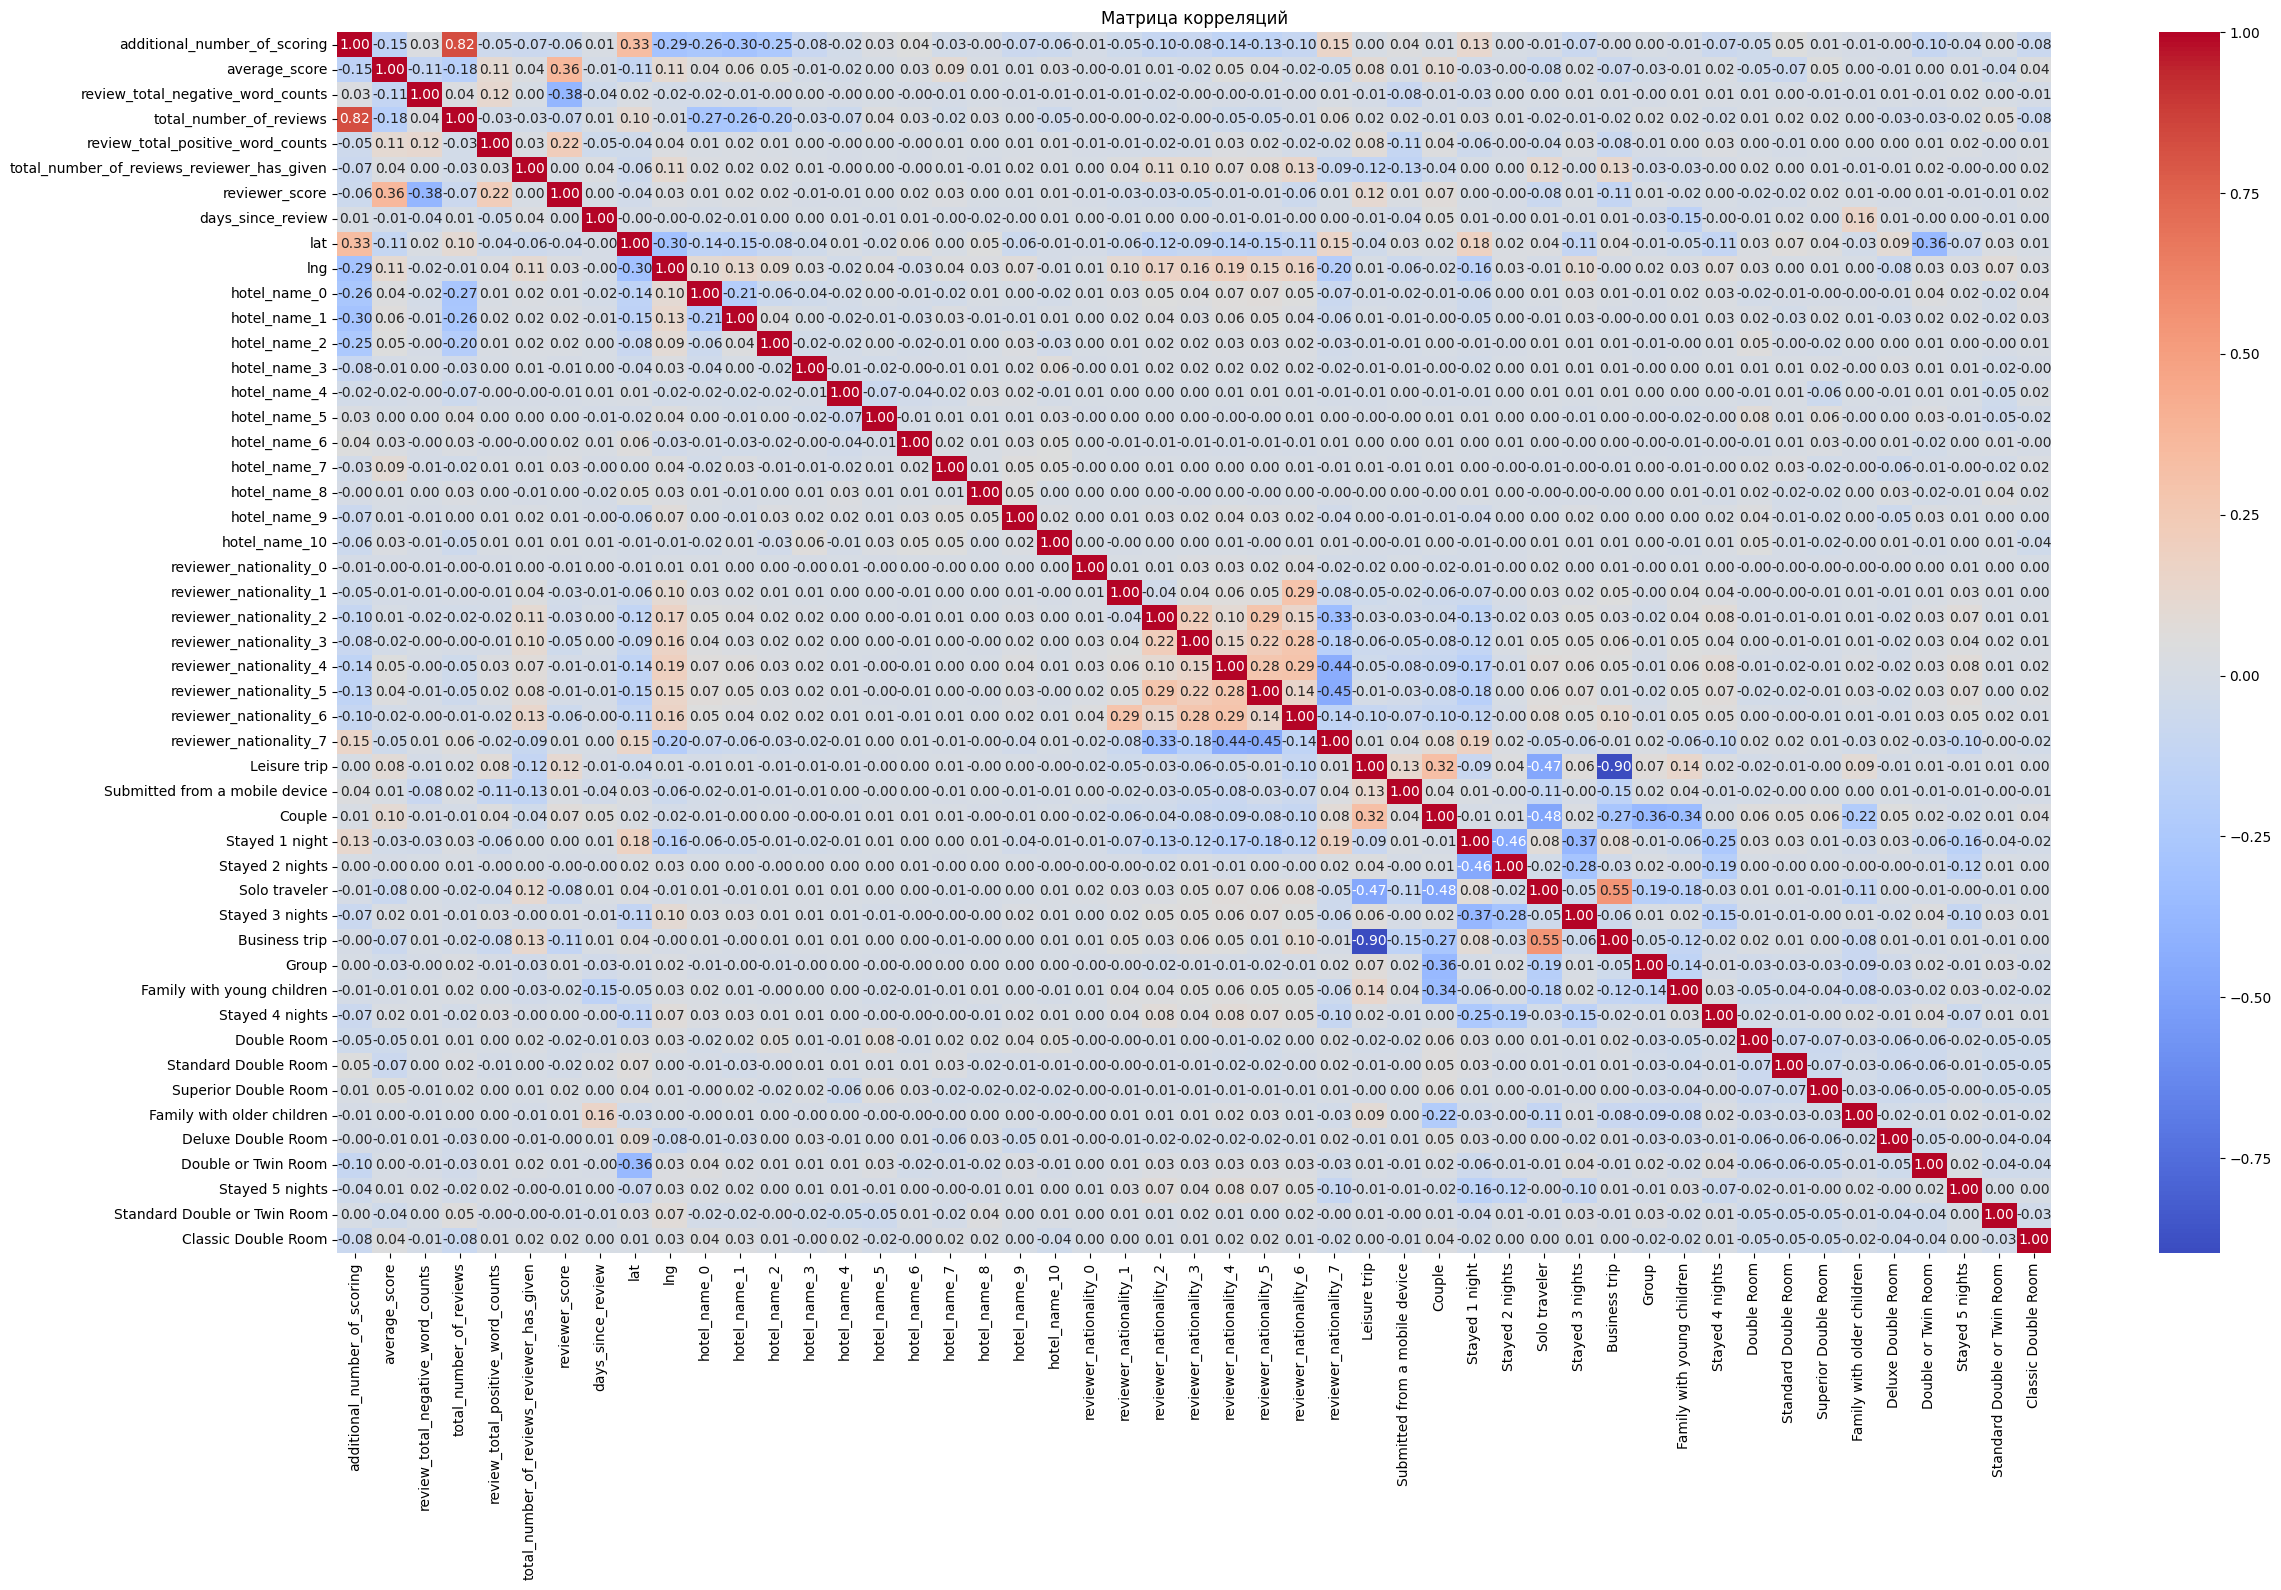

In [445]:
plt.figure(figsize=(25, 16))  # ширина, высота в дюймах
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

**Мультикорреляцию имеют следующие признаки:**
* Business trip - Leisure trip = -0.9 (удален будет признак Business trip - так как он встречается реже, а значит является менее важным фактором)
* total_number_if_reviews - additional_number_of_scoring = 0.82 (удален будет признак additional_number_of_scoring - так как total_number_if_reviews показывает общее количество пользователей)

In [450]:
# удаление мультикорреляционных признаков

df.drop(columns=['Business trip', 'additional_number_of_scoring'], inplace=True)

Данные готовы к машинному обучению

<h3>Машинное обучение</h3>

In [ ]:
X = df.drop(['reviewer_score'], axis=1)  
y = df['reviewer_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

regr = RandomForestRegressor(n_estimators=100, random_state=42)
regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.1252
R²: 0.4087
